In [1]:
# Import  pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("2019-Nov.csv")

# View structure and first few rows
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1048575 non-null  object 
 1   event_type     1048575 non-null  object 
 2   product_id     1048575 non-null  int64  
 3   category_id    1048575 non-null  float64
 4   category_code  716498 non-null   object 
 5   brand          894260 non-null   object 
 6   price          1048575 non-null  float64
 7   user_id        1048575 non-null  int64  
 8   user_session   1048575 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 72.0+ MB
None
                event_time event_type  product_id   category_id  \
0  2019-11-01 00:00:00 UTC       view     1003461  2.053010e+18   
1  2019-11-01 00:00:00 UTC       view     5000088  2.053010e+18   
2  2019-11-01 00:00:01 UTC       view    17302664  2.053010e+18   
3  2019-11-01 00:00:01 UTC       view     3601

In [2]:
print(df.isnull().sum())

event_time            0
event_type            0
product_id            0
category_id           0
category_code    332077
brand            154315
price                 0
user_id               0
user_session          0
dtype: int64


In [3]:
#HANDLING(FILLING THE NULL VALUES)

# Fill null category_code with a placeholder like "unknown_category"
df['category_code'] = df['category_code'].fillna('unknown_category')

# Fill null brand with a placeholder like 'unknown_brand'
df['brand'] = df['brand'].fillna('unknown_brand')


In [4]:
print(df.isnull().sum())

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64


In [5]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2.053010e+18,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2.053010e+18,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2.053010e+18,unknown_category,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2.053010e+18,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2.053010e+18,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [6]:
# Import datetime to handle timestamps
from datetime import datetime

# Convert event_time column to datetime format
df['event_time'] = pd.to_datetime(df['event_time'])

# Sort all rows by time for proper chronological session behavior
df = df.sort_values(by='event_time') 


In [7]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00+00:00,view,1003461,2.053010e+18,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00+00:00,view,5000088,2.053010e+18,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01+00:00,view,17302664,2.053010e+18,unknown_category,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01+00:00,view,3601530,2.053010e+18,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01+00:00,view,1004775,2.053010e+18,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2
...,...,...,...,...,...,...,...,...,...
1048544,2019-11-01 16:00:51+00:00,view,1004385,2.053010e+18,electronics.smartphone,oppo,776.08,566440870,ed2c9d43-5360-4e21-b035-94b3cfe93fa2
1048557,2019-11-01 16:00:51+00:00,view,26600058,2.053010e+18,unknown_category,lucente,95.24,524394236,43ed9cb4-ee8b-4b9b-960c-7fc6ec7ae46c
1048573,2019-11-01 16:00:52+00:00,view,28102605,2.053010e+18,unknown_category,vitebskiekovry,60.74,514317487,214ad989-b673-4259-bc05-3dd0235fd26c
1048572,2019-11-01 16:00:52+00:00,view,6000254,2.053010e+18,auto.accessories.alarm,starline,196.92,513687012,43e8351d-5a42-49bd-b15e-ecff1d382242


In [8]:
session_group = df.groupby('user_session')

session_features = session_group.agg({
    'event_time': ['min', 'max'],
    'event_type': lambda x: list(x),
    'category_code': lambda x: list(x.dropna().unique()), 
    'brand': pd.Series.nunique,
    'price': ['mean', 'sum'],
    'user_id': 'first'
})


In [9]:
session_features.columns = ['start_time', 'end_time', 'event_list', 'category_list', 'unique_brands', 'avg_price', 'total_price', 'user_id']


In [10]:
#  Calculate how long the session lasted (in seconds)
session_features['session_duration'] = (
    session_features['end_time'] - session_features['start_time']
).dt.total_seconds()

#  Count total number of actions (like 'view', 'cart', etc.) in the session
session_features['total_events'] = session_features['event_list'].apply(len)

#  Count how many times the user just viewed products
session_features['num_views'] = session_features['event_list'].apply(lambda x: x.count('view'))

#  Count how many items were added to cart
session_features['num_cart'] = session_features['event_list'].apply(lambda x: x.count('cart'))

#  Count how many items were actually purchased
session_features['num_purchase'] = session_features['event_list'].apply(lambda x: x.count('purchase'))


In [11]:
# Make user_session a column instead of index
session_features = session_features.reset_index()

# Show final preview
print(session_features.head())


                           user_session                start_time  \
0  00006bc8-78c7-4100-ba97-37352c9af491 2019-11-01 11:57:19+00:00   
1  00008ebc-a8c1-48c2-beb9-aa4448e93639 2019-11-01 13:11:19+00:00   
2  0000b0f0-9fb0-41a3-bdfa-3fa1d28b2e7c 2019-11-01 10:37:08+00:00   
3  0000cf90-3ea4-4526-aca3-a48a739b66f1 2019-11-01 15:02:17+00:00   
4  0000d82e-3614-4362-a1d3-2a56a895fdc6 2019-11-01 07:37:28+00:00   

                   end_time  \
0 2019-11-01 13:36:41+00:00   
1 2019-11-01 13:18:40+00:00   
2 2019-11-01 10:37:45+00:00   
3 2019-11-01 15:02:54+00:00   
4 2019-11-01 07:38:48+00:00   

                                          event_list  \
0  [view, view, view, view, view, view, view, vie...   
1                           [view, view, view, view]   
2                           [view, view, view, view]   
3                                       [view, view]   
4                                       [view, view]   

                                    category_list  unique_bra

In [12]:
session_features.columns

Index(['user_session', 'start_time', 'end_time', 'event_list', 'category_list',
       'unique_brands', 'avg_price', 'total_price', 'user_id',
       'session_duration', 'total_events', 'num_views', 'num_cart',
       'num_purchase'],
      dtype='object')

In [13]:
# Label burnout: long session, many views, no purchase
def label_burnout(row):
    if (row['session_duration'] > 600) and (row['num_views'] >= 5) and (row['num_purchase'] == 0):
        return 1
    else:
        return 0

# Apply to session_features
session_features['burnout'] = session_features.apply(label_burnout, axis=1)

# Preview
print(session_features[['session_duration', 'num_views', 'num_purchase', 'burnout']].head())


   session_duration  num_views  num_purchase  burnout
0            5962.0         13             0        1
1             441.0          4             0        0
2              37.0          4             0        0
3              37.0          2             0        0
4              80.0          2             0        0


In [14]:
## Creating a new Dataframe
required_df = session_features[[
    'total_events', 'num_views',
    'num_cart', 'num_purchase', 'avg_price', 'total_price', 'burnout'
]]


In [15]:
## EDA Analysis
# Class balance check
print(session_features['burnout'].value_counts())

burnout
0    226942
1     20364
Name: count, dtype: int64


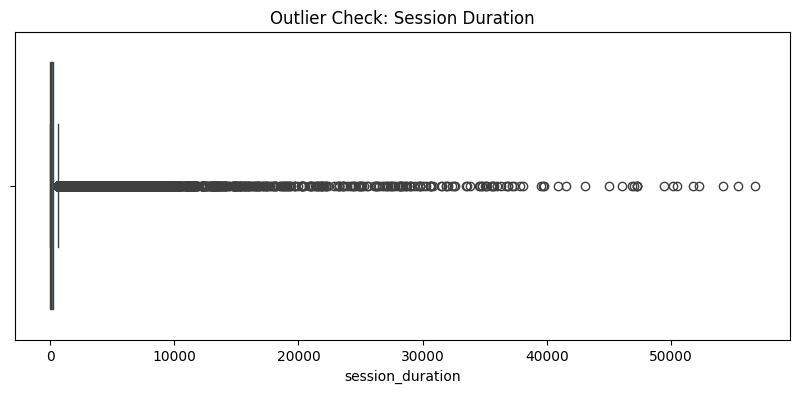

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing session_duration outliers
plt.figure(figsize=(10,4))
sns.boxplot(x=session_features['session_duration'])
plt.title("Outlier Check: Session Duration")
plt.show()


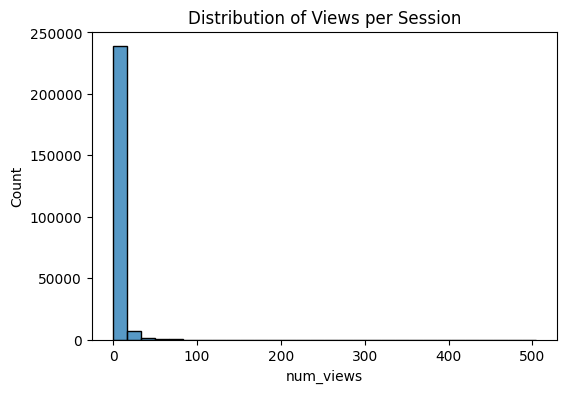

In [17]:
# Histogram of number of views
plt.figure(figsize=(6,4))
sns.histplot(session_features['num_views'], bins=30)
plt.title("Distribution of Views per Session")
plt.show()


In [18]:
# Define features and labels
X = required_df.drop(columns=['burnout'])
y = required_df['burnout']

In [19]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
##Model Training
# Import the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize the model
logreg = LogisticRegression(max_iter=1000)

# Train the model
logreg.fit(X_train, y_train)

# Make predictions
y_pred_logreg = logreg.predict(X_test)

# Evaluate using classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     45389
           1       0.76      0.51      0.61      4073

    accuracy                           0.95     49462
   macro avg       0.86      0.75      0.79     49462
weighted avg       0.94      0.95      0.94     49462



In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Step 1: Define features and target
X = required_df.drop(columns=['burnout'])
y = required_df['burnout']

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     67990
           1       0.56      0.55      0.55      6202

    accuracy                           0.93     74192
   macro avg       0.76      0.76      0.76     74192
weighted avg       0.93      0.93      0.93     74192



In [22]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Use same X and y from earlier

# Step 2: Split is already done (X_train, X_test, y_train, y_test)

# Step 3: Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     67990
           1       0.56      0.55      0.55      6202

    accuracy                           0.93     74192
   macro avg       0.76      0.75      0.76     74192
weighted avg       0.93      0.93      0.93     74192



In [23]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=10000)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     67990
           1       0.79      0.46      0.58      6202

    accuracy                           0.94     74192
   macro avg       0.87      0.73      0.78     74192
weighted avg       0.94      0.94      0.94     74192



In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Step 1: Create and train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune this later
knn_model.fit(X_train, y_train)

# Step 2: Predict on test set
y_pred_knn = knn_model.predict(X_test)

# Step 3: Evaluate performance
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     67990
           1       0.62      0.49      0.55      6202

    accuracy                           0.93     74192
   macro avg       0.79      0.73      0.76     74192
weighted avg       0.93      0.93      0.93     74192



In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Step 1: Initialize the model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Step 2: Fit the model
xgb_model.fit(X_train, y_train)

# Step 3: Predict
y_pred_xgb = xgb_model.predict(X_test)

# Step 4: Evaluate
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))


c:\Users\test\OneDrive\Desktop\Digital_burnout\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:41:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     67990
           1       0.76      0.51      0.61      6202

    accuracy                           0.95     74192
   macro avg       0.86      0.75      0.79     74192
weighted avg       0.94      0.95      0.94     74192



In [26]:
##Applying SMOTE(Synthetic Minority Over-Sampling Technique) to oversample the minority class(burnout=1)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Define features and target from the clean required_df
X = required_df.drop(columns=['burnout'])
y = required_df['burnout']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Train-test split on balanced data
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)


In [27]:
from sklearn.linear_model import LogisticRegression

logreg_smote = LogisticRegression(max_iter=1000)
logreg_smote.fit(X_train_smote, y_train_smote)

y_pred_logreg_smote = logreg_smote.predict(X_test_smote)
print("Logistic Regression after SMOTE:")
print(classification_report(y_test_smote, y_pred_logreg_smote))


Logistic Regression after SMOTE:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     45345
           1       0.91      0.88      0.89     45432

    accuracy                           0.90     90777
   macro avg       0.90      0.90      0.90     90777
weighted avg       0.90      0.90      0.90     90777



In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_model.predict(X_test_smote)

print("Random Forest after SMOTE:")
print(classification_report(y_test_smote, y_pred_rf_smote))


Random Forest after SMOTE:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     45345
           1       0.91      0.92      0.91     45432

    accuracy                           0.91     90777
   macro avg       0.91      0.91      0.91     90777
weighted avg       0.91      0.91      0.91     90777



In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

y_pred_dt_smote = dt_model.predict(X_test_smote)

print("Decision Tree after SMOTE:")
print(classification_report(y_test_smote, y_pred_dt_smote))


Decision Tree after SMOTE:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     45345
           1       0.91      0.91      0.91     45432

    accuracy                           0.91     90777
   macro avg       0.91      0.91      0.91     90777
weighted avg       0.91      0.91      0.91     90777



In [30]:
from sklearn.svm import LinearSVC

svm_model_smote = LinearSVC(max_iter=10000)
svm_model_smote.fit(X_train_smote, y_train_smote)

y_pred_svm_smote = svm_model_smote.predict(X_test_smote)
print("SVM after SMOTE:")
print(classification_report(y_test_smote, y_pred_svm_smote))

SVM after SMOTE:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     45345
           1       0.91      0.85      0.88     45432

    accuracy                           0.88     90777
   macro avg       0.88      0.88      0.88     90777
weighted avg       0.88      0.88      0.88     90777



In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn_model_smote = KNeighborsClassifier(n_neighbors=5)
knn_model_smote.fit(X_train_smote, y_train_smote)

y_pred_knn_smote = knn_model_smote.predict(X_test_smote)
print("KNN after SMOTE:")
print(classification_report(y_test_smote, y_pred_knn_smote))

KNN after SMOTE:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     45345
           1       0.88      0.96      0.92     45432

    accuracy                           0.91     90777
   macro avg       0.92      0.91      0.91     90777
weighted avg       0.92      0.91      0.91     90777



In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Step 1: Initialize and train the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)

# Step 2: Predict on SMOTE test set
y_pred_xgb_smote = xgb_model.predict(X_test_smote)

# Step 3: Evaluate the results
print("XGBoost after SMOTE:")
print(classification_report(y_test_smote, y_pred_xgb_smote))


c:\Users\test\OneDrive\Desktop\Digital_burnout\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:42:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost after SMOTE:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     45345
           1       0.87      0.99      0.93     45432

    accuracy                           0.92     90777
   macro avg       0.93      0.92      0.92     90777
weighted avg       0.93      0.92      0.92     90777



In [35]:
# Model Selection and SMOTE Application Summary

#To address class imbalance in the burnout prediction dataset, SMOTE (Synthetic Minority Over-sampling Technique) was applied to generate 
# synthetic examples for the minority class (burnout = 1). This ensured that the machine learning models trained on a
# balanced representation of both classes.

#After applying SMOTE, six different models were retrained and evaluated using the F1-score for the minority class, 
# as it provides a balanced measure of precision and recall — crucial for imbalanced classification tasks.

#The F1-scores for burnout = 1 across the models were as follows:
    
#XGBoost: 0.93
#K-Nearest Neighbors (KNN): 0.92
#Random Forest: 0.91
#Decision Tree: 0.91
#Logistic Regression: 0.89
#Support Vector Machine (SVM): 0.88

#Based on these results, the top three models selected for final analysis were:

#XGBoost
#K-Nearest Neighbors
#Random Forest

#These models demonstrated the highest ability to detect burnout sessions effectively and consistently, 
# justifying their selection for final reporting and interpretation.